# Code snippet for downscaling satellite images applied to worldview images of Flask Glacier, Antarcitca


In [120]:
import rioxarray
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
from rasterio.enums import Resampling
import numpy as np

images = ['/Users/jkingslake/Documents/projects/current_projects/AntPen_NSF_NERC/remote sensing/worldview/6155_2025apr15_Kingslake_2024_25_Imagery/imagery/WV01_20250220165639_102001010B8E9300_25FEB20165639-P1BS-509368717060_01_P001_u16ns3031.tif',
'/Users/jkingslake/Documents/projects/current_projects/AntPen_NSF_NERC/remote sensing/worldview/6155_2025apr15_Kingslake_2024_25_Imagery/imagery/WV03_20250125134954_10400100A1BD5000_25JAN25134954-M1BS-509294984070_01_P008_u16ns3031.tif',
'/Users/jkingslake/Documents/projects/current_projects/AntPen_NSF_NERC/remote sensing/worldview/6155_2025apr15_Kingslake_2024_25_Imagery/imagery/WV02_20250102125224_103001010C7CFB00_25JAN02125224-M1BS-509231708010_01_P008_u16ns3031.tif',
'/Users/jkingslake/Documents/projects/current_projects/AntPen_NSF_NERC/remote sensing/worldview/6204_2025sep25/imagery/WV02_20250925131603_103001011B30DC00_25SEP25131601-M1BS-200009731139_01_P001_u16rf3031.tif']
# obtain just the image names
names = [image.split('/')[-1] for image in images]
# bounds found from qgis by zooming to the right extent and using the bounding box plugin
bounds = [-2375649.0447250404,1221664.4483834528,-2367436.9296156955,1228200.4785131793]

for name, image in zip(names, images):
    print(name)
    print(image)
    print('---')

    high_res = rioxarray.open_rasterio(image, chunks = "auto", masked = True).rio.clip_box(*bounds).load()

    new_width = int(high_res.rio.width // 1.5)
    new_height = int(high_res.rio.height // 1.5)
    low_res = high_res.rio.reproject(
                    high_res.rio.crs,
                    shape=(new_height, new_width),
                    resampling=Resampling.bilinear,
                )
    low_res.rio.to_raster(f'/Users/jkingslake/Documents/projects/current_projects/AntPen_NSF_NERC/remote sensing/worldview/downscaled_for_BAS/downscaled_{name}', compress='LZW')
    
    if len(low_res.band) > 1:
       rgb = low_res.isel(band =[4, 2, 1])
    else:
       rgb = low_res
    lo = np.nanpercentile(rgb, 2, axis=(1,2), keepdims=True)
    hi = np.nanpercentile(rgb, 98, axis=(1,2), keepdims=True)

    normalized_array = (rgb - lo) / (hi - lo)

    stretched = np.clip(normalized_array, 0, 1) * 255
    stretched = stretched.astype(np.uint8)
    stretched.rio.to_raster(f'/Users/jkingslake/Documents/projects/current_projects/AntPen_NSF_NERC/remote sensing/worldview/downscaled_for_BAS/downscaled_{name}.png', driver='PNG')

WV01_20250220165639_102001010B8E9300_25FEB20165639-P1BS-509368717060_01_P001_u16ns3031.tif
/Users/jkingslake/Documents/projects/current_projects/AntPen_NSF_NERC/remote sensing/worldview/6155_2025apr15_Kingslake_2024_25_Imagery/imagery/WV01_20250220165639_102001010B8E9300_25FEB20165639-P1BS-509368717060_01_P001_u16ns3031.tif
---
WV03_20250125134954_10400100A1BD5000_25JAN25134954-M1BS-509294984070_01_P008_u16ns3031.tif
/Users/jkingslake/Documents/projects/current_projects/AntPen_NSF_NERC/remote sensing/worldview/6155_2025apr15_Kingslake_2024_25_Imagery/imagery/WV03_20250125134954_10400100A1BD5000_25JAN25134954-M1BS-509294984070_01_P008_u16ns3031.tif
---
WV02_20250102125224_103001010C7CFB00_25JAN02125224-M1BS-509231708010_01_P008_u16ns3031.tif
/Users/jkingslake/Documents/projects/current_projects/AntPen_NSF_NERC/remote sensing/worldview/6155_2025apr15_Kingslake_2024_25_Imagery/imagery/WV02_20250102125224_103001010C7CFB00_25JAN02125224-M1BS-509231708010_01_P008_u16ns3031.tif
---
WV02_20250

/Users/jkingslake/.local/share/mamba/envs/pdem_tools/lib/python3.13/site-packages/xarray/core/duck_array_ops.py:237: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


In [56]:
def rgb_plot(ds):
    rgb = ds.isel(band =[4, 2, 1])
    min_val = rgb.min()
    max_val = rgb.max()
    normalized_array = (rgb - min_val) / (max_val - min_val)

    fig, ax = plt.subplots()

    normalized_array.plot.imshow(ax=ax)
    plt.gca().set_aspect('equal') 
    return fig, ax, normalized_array

In [117]:
rgb = low_res
lo = np.nanpercentile(rgb, 2, axis=(1,2), keepdims=True)
hi = np.nanpercentile(rgb, 98, axis=(1,2), keepdims=True)

normalized_array = (rgb - lo) / (hi - lo)

stretched = np.clip(normalized_array, 0, 1) * 255
stretched = stretched.astype(np.uint8)

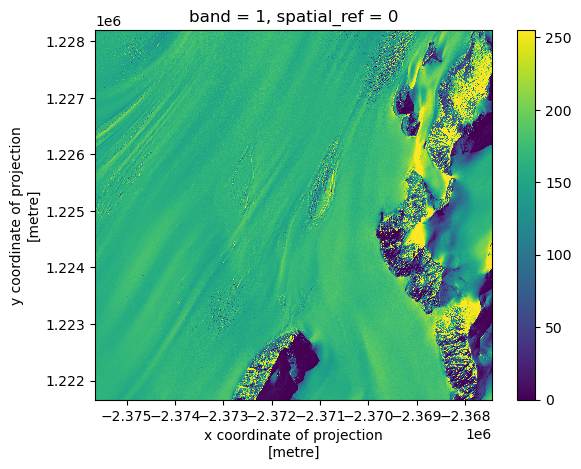

In [119]:
stretched.plot()

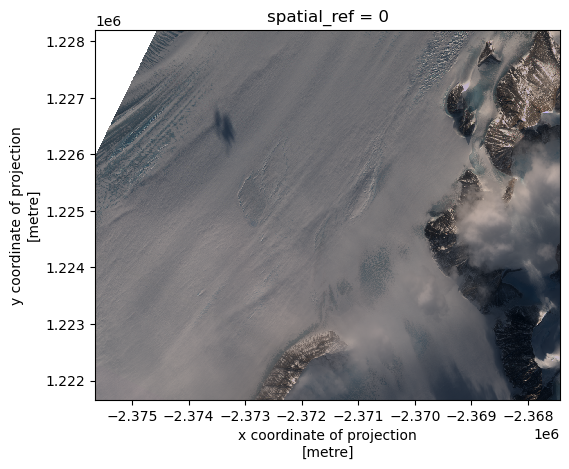

In [57]:
fig, ax, normalized_array = rgb_plot(low_res)

In [70]:
normalized_array.astype(np.uint8).rio.to_raster('downscaled_example.png', driver='PNG')

/Users/jkingslake/.local/share/mamba/envs/pdem_tools/lib/python3.13/site-packages/xarray/core/duck_array_ops.py:237: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


In [80]:
(normalized_array * 255).astype(np.uint8).rio.to_raster('downscaled_example.png', driver='PNG')

In [ ]:
    stretched = np.clip((rgb.values - lo) / (hi - lo + 1e-6), 0, 1) * 255


In [ ]:
def rgb_plot(ds):
    rgb = ds.isel(band =[4, 2, 1])
   
    lo = np.nanpercentile(rgb, 2, axis=(1,2), keepdims=True)
    hi = np.nanpercentile(rgb, 98, axis=(1,2), keepdims=True)

    normalized_array = (rgb - lo) / (hi - lo)

    stretched = np.clip(normalized_array, 0, 1) * 255
    stretched = stretched.astype(np.uint8)

    fig, ax = plt.subplots()

    stretched.plot.imshow(ax=ax)
    plt.gca().set_aspect('equal') 
    return fig, ax, stretched

/Users/jkingslake/.local/share/mamba/envs/pdem_tools/lib/python3.13/site-packages/xarray/core/duck_array_ops.py:237: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'spatial_ref = 0'}, xlabel='x coordinate of projection\n[metre]', ylabel='y coordinate of projection\n[metre]'>,
 <xarray.DataArray (band: 3, y: 3264, x: 4135)> Size: 40MB
 array([[[  0,   0,   0, ..., 255, 255, 255],
         [  0,   0,   0, ..., 255, 255, 255],
         [  0,   0,   0, ..., 255, 255, 255],
         ...,
         [214, 215, 213, ...,  65,  57,  61],
         [215, 213, 214, ...,  64,  63,  58],
         [213, 215, 214, ...,  68,  69,  61]],
 
        [[  0,   0,   0, ..., 255, 255, 255],
         [  0,   0,   0, ..., 255, 255, 255],
         [  0,   0,   0, ..., 255, 255, 255],
         ...,
         [221, 222, 221, ...,  78,  72,  74],
         [221, 220, 221, ...,  77,  74,  73],
         [220, 222, 222, ...,  80,  82,  76]],
 
        [[  0,   0,   0, ..., 255, 255, 255],
         [  0,   0,   0, ..., 255, 255, 255],
         [  0,   0,   0, ..., 255, 255, 255],
         ...,
         [236, 236, 235, ...,

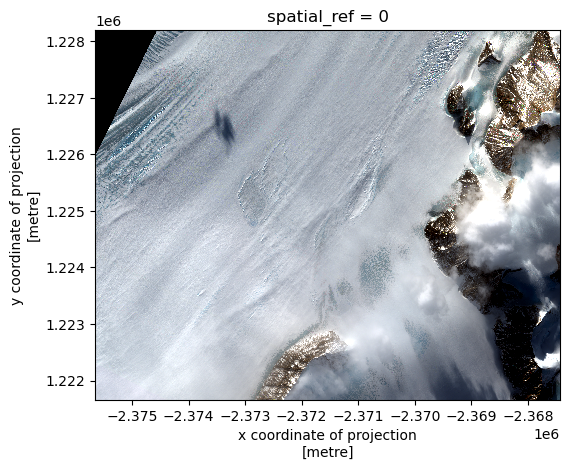

In [110]:
rgb_plot(high_res)

In [ ]:
# compute percentile stretch
rgb = high_res.isel(band =[4, 2, 1])

lo = np.nanpercentile(rgb, 22, axis=(1,2), keepdims=True)
hi = np.nanpercentile(rgb, 98, axis=(1,2), keepdims=True)


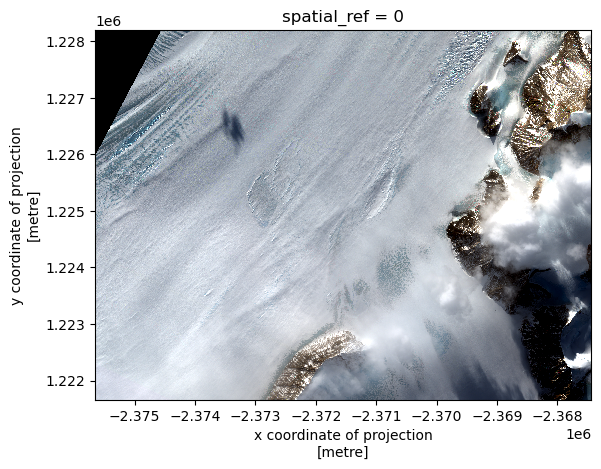

In [106]:
stretched.plot.imshow()

In [107]:
stretched.rio.to_raster('downscaled_example.png', driver='PNG')

In [83]:
rgb.percentile

AttributeError: 'DataArray' object has no attribute 'percentile'

In [ ]:
low_res.rio.to_raster(f'/Users/jkingslake/Documents/projects/current_projects/AntPen_NSF_NERC/remote sensing/worldview/downscaled_for_BAS/downscaled_{name}.png'

In [53]:
high_res = rioxarray.open_rasterio(image, chunks = "auto", masked = True).rio.clip_box(*bounds).load()
high_res

<xarray.DataArray (band: 8, y: 3264, x: 4135)> Size: 432MB
array([[[  nan,   nan,   nan, ..., 2158., 2163., 2171.],
        [  nan,   nan,   nan, ..., 2161., 2176., 2153.],
        [  nan,   nan,   nan, ..., 2179., 2161., 2143.],
        ...,
        [1986., 2004., 2001., ..., 1300., 1270., 1273.],
        [1999., 1991., 1994., ..., 1295., 1257., 1257.],
        [2001., 2001., 1994., ..., 1295., 1290., 1290.]],

       [[  nan,   nan,   nan, ..., 2436., 2458., 2512.],
        [  nan,   nan,   nan, ..., 2456., 2456., 2496.],
        [  nan,   nan,   nan, ..., 2467., 2483., 2478.],
        ...,
        [2236., 2234., 2229., ..., 1323., 1267., 1305.],
        [2236., 2223., 2220., ..., 1318., 1289., 1287.],
        [2234., 2236., 2225., ..., 1332., 1321., 1296.]],

       [[  nan,   nan,   nan, ..., 2581., 2585., 2629.],
        [  nan,   nan,   nan, ..., 2575., 2597., 2634.],
        [  nan,   nan,   nan, ..., 2580., 2609., 2561.],
        ...,
...
        [2123., 2147., 2112., ...,  898.,  790.,  833.],
        [2121., 2125., 2119., ...,  844.,  808.,  818.],
        [2121., 2121., 2119., ...,  915.,  892.,  836.]],

       [[  nan,   nan,   nan, ..., 2628., 2680., 2711.],
        [  nan,   nan,   nan, ..., 2645., 2694., 2720.],
        [  nan,   nan,   nan, ..., 2663., 2695., 2647.],
        ...,
        [2100., 2108., 2083., ...,  691.,  579.,  613.],
        [2097., 2095., 2102., ...,  699.,  658.,  601.],
        [2089., 2116., 2106., ...,  770.,  748.,  621.]],

       [[  nan,   nan,   nan, ..., 2062., 2064., 2088.],
        [  nan,   nan,   nan, ..., 2068., 2100., 2113.],
        [  nan,   nan,   nan, ..., 2094., 2090., 2064.],
        ...,
        [1647., 1657., 1649., ...,  504.,  445.,  475.],
        [1643., 1645., 1645., ...,  482.,  418.,  375.],
        [1651., 1655., 1655., ...,  529.,  529.,  416.]]],
      shape=(8, 3264, 4135), dtype=float32)
Coordinates:
  * band         (band) int64 64B 1 2 3 4 5 6 7 8
  * x            (x) float64 33kB -2.376e+06 -2.376e+06 ... -2.367e+06
  * y            (y) float64 26kB 1.228e+06 1.228e+06 ... 1.222e+06 1.222e+06
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_IMAGEDESCRIPTION:  [-1.]
    TIFFTAG_DATETIME:          2025:09:25 14:24:17
    TIFFTAG_COPYRIGHT:         Copyright 2025 Maxar Technologies
    AREA_OR_POINT:             Area
    STATISTICS_MAXIMUM:        3479
    STATISTICS_MEAN:           1629.8806014876
    STATISTICS_MINIMUM:        435
    STATISTICS_STDDEV:         333.13536350684
    STATISTICS_VALID_PERCENT:  55.06
    scale_factor:              1.0
    add_offset:                0.0

In [58]:
import numpy as np

In [61]:
def tiff_to_png_rgb(ds, dst_path, bands=(4,3,2), pmin=2, pmax=98):
    # open GeoTIFF
    #ds = rioxarray.open_rasterio(src_path)

    # select bands (rioxarray band index is usually 1-based)
    rgb = ds.isel(band=list(bands))

    # compute percentile stretch
    lo = np.percentile(rgb.values, pmin, axis=(1,2), keepdims=True)
    hi = np.percentile(rgb.values, pmax, axis=(1,2), keepdims=True)

    stretched = np.clip((rgb.values - lo) / (hi - lo + 1e-6), 0, 1) * 255
    stretched = stretched.astype(np.uint8)

    # stacked back to DataArray
    rgb_stretched = rgb.copy(data=stretched)

    # drop georeference (PNG has no CRS)
    #rgb_stretched.rio.write_crs(None, inplace=True)

    # export as PNG
    rgb_stretched.rio.to_raster(dst_path, driver="PNG")

# single file
tiff_to_png_rgb(high_res, "output.png")


/var/folders/kl/3mt9f4qs1559xwy3mr60s7980000gp/T/ipykernel_18615/646987485.py:13: RuntimeWarning: invalid value encountered in cast
  stretched = stretched.astype(np.uint8)


OverflowError: Unable to convert nodata value (65535.0) to new dtype (uint8).

In [66]:
    # compute percentile stretch

rgb = high_res.isel(band=[4, 2, 1])

lo = np.percentile(rgb.values, 0.02, axis=(1,2), keepdims=True)
hi = np.percentile(rgb.values, 0.98, axis=(1,2), keepdims=True)

stretched = np.clip((rgb - lo) / (hi - lo + 1e-6), 0, 1) * 255
stretched = stretched.astype(np.uint8)

/Users/jkingslake/.local/share/mamba/envs/pdem_tools/lib/python3.13/site-packages/xarray/core/duck_array_ops.py:237: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


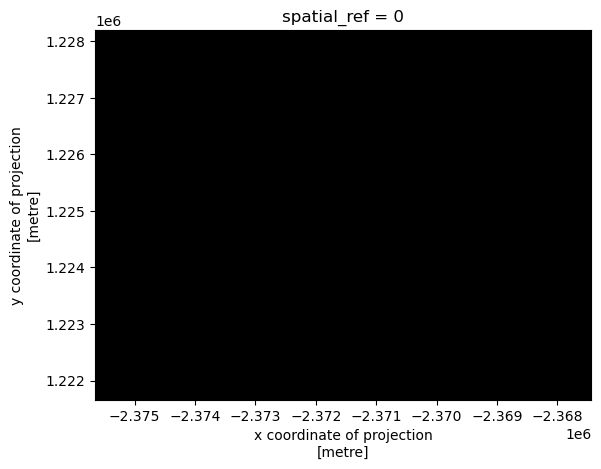

In [68]:
stretched.plot.imshow()

In [65]:
stretched

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], shape=(3, 3264, 4135), dtype=uint8)

In [49]:
low_res = low_res.where(low_res<65535)
low_res

<xarray.DataArray (band: 8, y: 1632, x: 2067)> Size: 108MB
array([[[  nan,   nan,   nan, ..., 2153., 2159., 2164.],
        [  nan,   nan,   nan, ..., 2151., 2167., 2157.],
        [  nan,   nan,   nan, ..., 2163., 2166., 2143.],
        ...,
        [1994., 1999., 1994., ..., 1313., 1310., 1305.],
        [1998., 1998., 1993., ..., 1308., 1298., 1280.],
        [1997., 2000., 1997., ..., 1301., 1293., 1276.]],

       [[  nan,   nan,   nan, ..., 2452., 2445., 2476.],
        [  nan,   nan,   nan, ..., 2451., 2465., 2476.],
        [  nan,   nan,   nan, ..., 2465., 2482., 2452.],
        ...,
        [2224., 2220., 2220., ..., 1328., 1329., 1322.],
        [2232., 2222., 2221., ..., 1335., 1323., 1307.],
        [2231., 2227., 2226., ..., 1319., 1317., 1301.]],

       [[  nan,   nan,   nan, ..., 2572., 2572., 2603.],
        [  nan,   nan,   nan, ..., 2570., 2585., 2593.],
        [  nan,   nan,   nan, ..., 2578., 2602., 2568.],
        ...,
...
        [2114., 2116., 2107., ...,  789.,  821.,  868.],
        [2130., 2121., 2119., ...,  799.,  841.,  846.],
        [2123., 2122., 2115., ...,  834.,  875.,  841.]],

       [[  nan,   nan,   nan, ..., 2618., 2638., 2689.],
        [  nan,   nan,   nan, ..., 2626., 2670., 2672.],
        [  nan,   nan,   nan, ..., 2661., 2682., 2634.],
        ...,
        [2107., 2092., 2097., ...,  548.,  599.,  657.],
        [2108., 2094., 2098., ...,  575.,  647.,  647.],
        [2100., 2094., 2080., ...,  640.,  715.,  660.]],

       [[  nan,   nan,   nan, ..., 2048., 2064., 2086.],
        [  nan,   nan,   nan, ..., 2042., 2085., 2083.],
        [  nan,   nan,   nan, ..., 2082., 2092., 2054.],
        ...,
        [1648., 1648., 1645., ...,  335.,  366.,  436.],
        [1654., 1651., 1651., ...,  348.,  406.,  459.],
        [1649., 1646., 1636., ...,  398.,  477.,  448.]]],
      shape=(8, 1632, 2067), dtype=float32)
Coordinates:
  * x            (x) float64 17kB -2.376e+06 -2.376e+06 ... -2.367e+06
  * y            (y) float64 13kB 1.228e+06 1.228e+06 ... 1.222e+06 1.222e+06
  * band         (band) int64 64B 1 2 3 4 5 6 7 8
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_IMAGEDESCRIPTION:  [-1.]
    TIFFTAG_DATETIME:          2025:09:25 14:24:17
    TIFFTAG_COPYRIGHT:         Copyright 2025 Maxar Technologies
    AREA_OR_POINT:             Area
    STATISTICS_MAXIMUM:        3479
    STATISTICS_MEAN:           1629.8806014876
    STATISTICS_MINIMUM:        435
    STATISTICS_STDDEV:         333.13536350684
    STATISTICS_VALID_PERCENT:  55.06
    scale_factor:              1.0
    add_offset:                0.0
    _FillValue:                65535

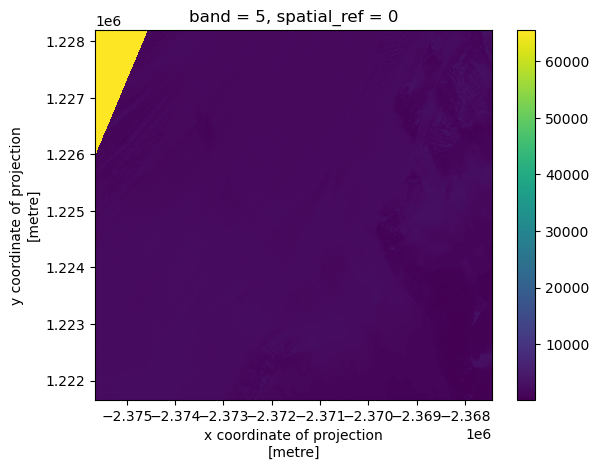

In [42]:
low_res.isel(band = 4).plot.imshow()